In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

In [3]:
df.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                   

In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [6]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [7]:
#Drop the Cabin column 
df.drop("Cabin", axis=1, inplace=True)

In [8]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

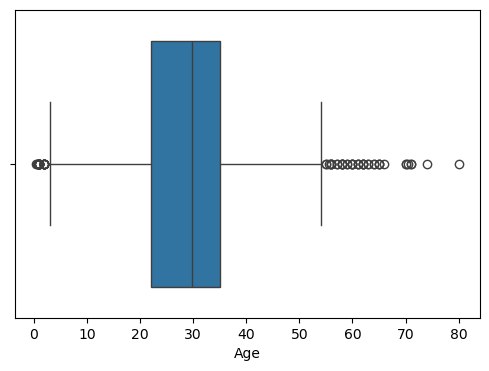

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns 
# Detect outliers
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Age"])
plt.show()

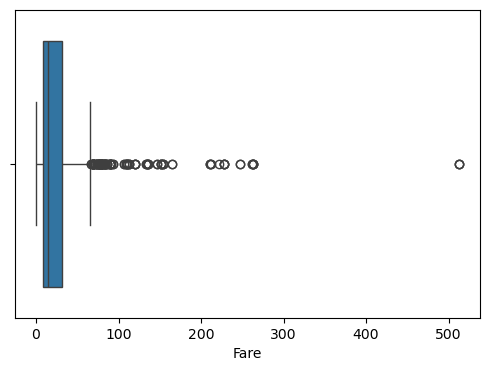

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Fare"])
plt.show()

In [15]:
# Remove outliers using IQR
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["Fare"] >= lower) &
        (df["Fare"] <= upper)]

In [16]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["Age"] >= lower) &
        (df["Age"] <= upper)]

In [17]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [19]:
import numpy as np
df["IsAlone"] = np.where(df["FamilySize"] == 1, 1, 0)


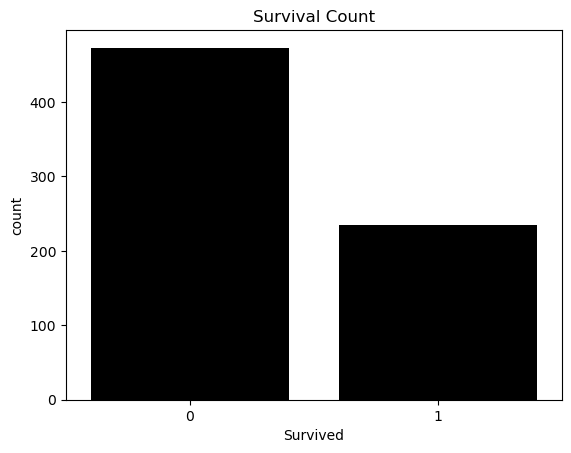

In [29]:
sns.countplot(x="Survived", data=df ,color ="black")
plt.title("Survival Count")
plt.show()

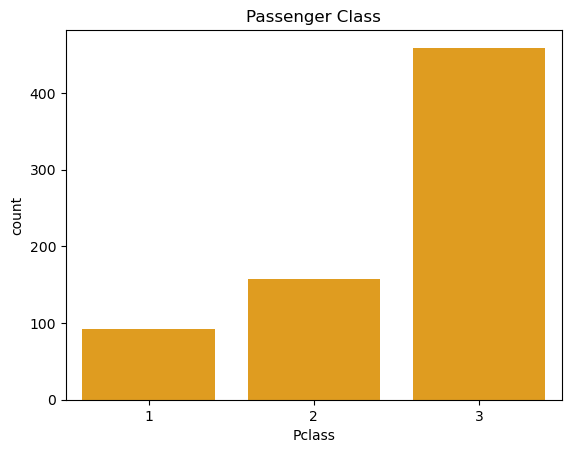

In [28]:
sns.countplot(x="Pclass", data=df , color = "orange")
plt.title("Passenger Class")
plt.show()

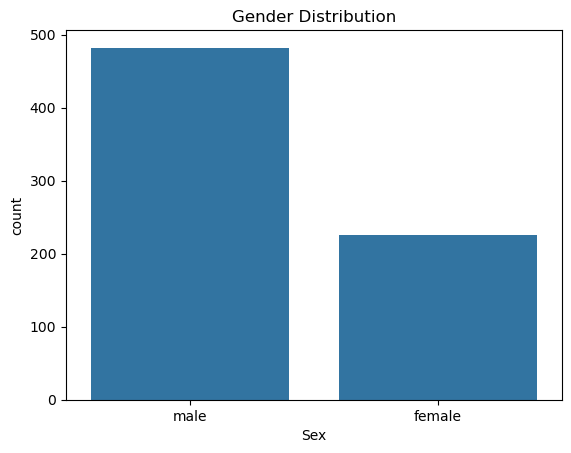

In [27]:
sns.countplot(x="Sex", data=df)
plt.title("Gender Distribution")
plt.show()

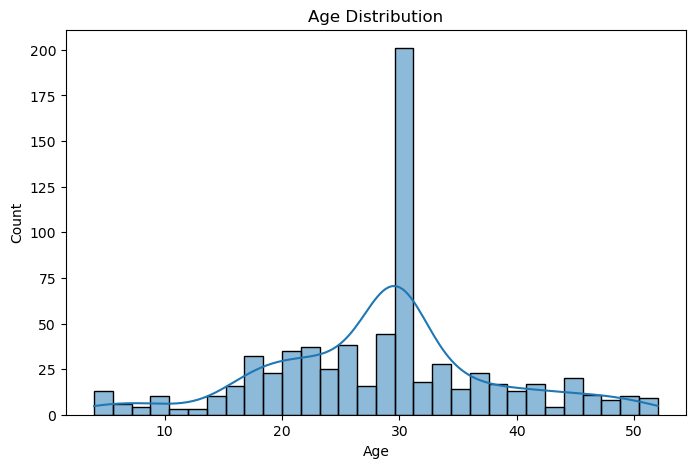

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

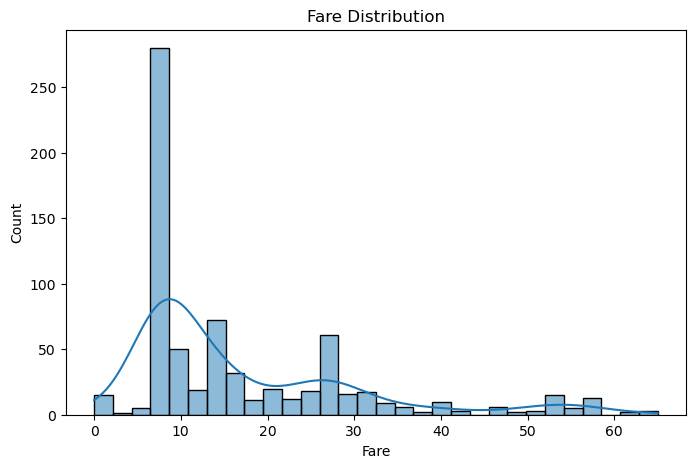

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(df["Fare"], bins=30, kde=True)
plt.title("Fare Distribution")
plt.show()


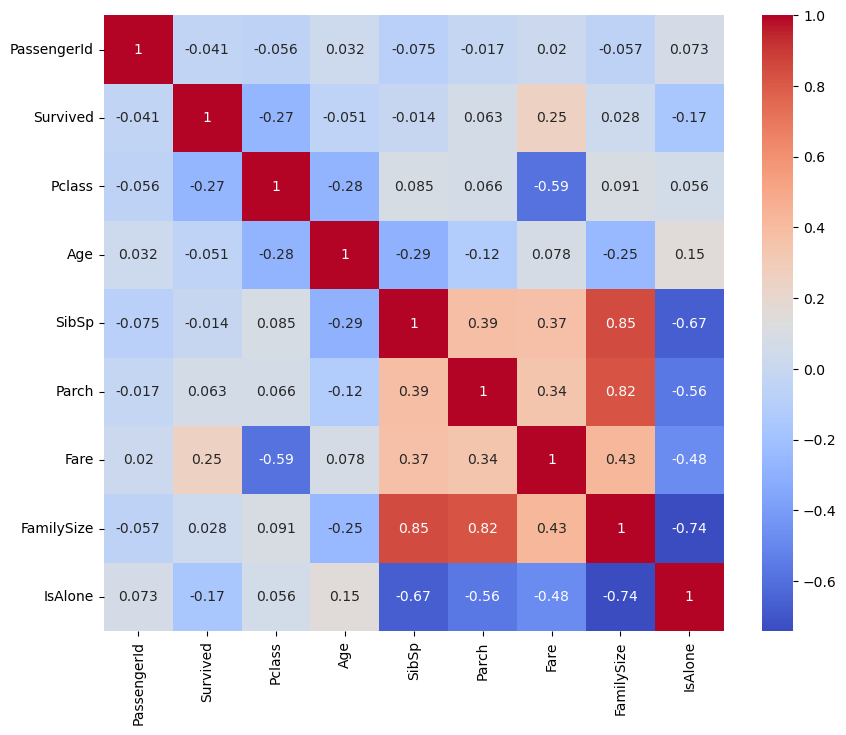

In [32]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [33]:
df.to_csv("Titanic_Cleaned.csv", index=False)

## Project Observations

Include observations like:

1.Age had many missing values and was filled using the median.

2.Cabin was removed because most values were missing.

3.Fare contained several outliers, which were removed using the IQR method.

4.Three new features (FamilySize, IsAlone, and FarePerPerson) were created to improve predictive capability.

5.The cleaned dataset is now suitable for machine learning.

## Summary

In this project, I performed Exploratory Data Analysis (EDA) and Feature Engineering on the Titanic dataset. I explored the dataset by examining its structure, data types, statistical summary, missing values, duplicate records, and outliers. Missing values were handled using appropriate techniques such as mean, median, and mode, while duplicate records were removed to improve data quality.

I also created new meaningful features, including FamilySize, IsAlone, and FarePerPerson, to enhance the dataset and improve its usefulness for machine learning models. Various visualizations such as histograms, boxplots, count plots, and a correlation heatmap were used to understand data distributions and relationships between variables.

The final output of this project was a clean, well-prepared dataset that is ready for machine learning and predictive analysis.